In [1]:
# Parameters
BATCH_MODE = "true"

# 3b. Décisions typées « système 1 » : décider sans générer
**Navigation** : [Index](README.md) | [<< Précédent](03_Structured_Outputs.ipynb) | [Suivant >>](04_Function_Calling.ipynb)

`03_Structured_Outputs` obtenait une décision d'un LLM **en la générant** : on force le modèle à
produire du JSON conforme à un schéma, puis on parse. Cette voie marche, mais elle paie le prix
d'un LLM : génération token par token, hallucination possible, coût par question.

Il existe une autre voie, discutée depuis longtemps et remise en avant en 2026 : **un petit modèle
de décision** qui reçoit un état et des questions *typées*, et rend en une seule passe une
distribution calibrée sur des options déclarées d'avance — sans générer une ligne de texte. Le
contrat public le plus répandu définit trois types de questions : `choice` (catégoriel),
`score` (ordinal) et `noul` (binaire). Une dizaine d'implémentations ouvertes le servent déjà.

Ce notebook pose la question que le dépôt ne posait nulle part : **quand un petit modèle de
décision suffit-il, et que perd-on hors du domaine d'entraînement ?** Pour y répondre, il compare
sur les *mêmes questions typées* deux familles extrêmes :

| Famille | Principe | Coût par question |
|---|---|---|
| **Témoin classique** | TF-IDF + régression logistique, entraîné sur le domaine | ~0 (CPU, microsecondes) |
| **LLM gelé lu sur ses logits** | aucun entraînement : on lit la log-probabilité de chaque option sur un modèle déjà servi | une passe de forward |

Les familles à checkpoint externe (laya, Kev, jevlike — voir conclusion) sont des tranches
suivantes de l'issue #17883 : elles ne sont pas substituées par un jouet ici.

In [2]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Périphérique d'exécution :", DEVICE)

Périphérique d'exécution : cuda


## 1. Le contrat : des questions typées, un espace de réponses fermé

Une question typée déclare **à l'avance** l'espace des réponses possibles. Pour le type
`choice`, on déclare les N options ; le modèle ne rend jamais autre chose qu'une distribution
sur ces N options. Le type `noul` est le cas binaire (nommé d'après ses deux options),
et le type `score` déclare une échelle ordinale de niveaux.

In [3]:
CHOICE, NOUL, SCORE = "choice", "noul", "score"


class Question:
    """Une question typée : un état soumis au modèle + un espace de réponses déclaré."""

    def __init__(self, kind, state, options):
        assert kind in (CHOICE, NOUL, SCORE)
        assert len(options) >= 2
        self.kind = kind
        self.state = state
        self.options = tuple(options)

    def decide(self, scores, temperature=1.0):
        """Ramène n'importe quel vecteur de scores à une distribution sur les options.

        C'est tout le contrat : quoi que produise un moteur, la réponse vit dans
        l'espace fermé des options déclarées.
        """
        s = np.asarray(scores, dtype=float)
        z = (s - s.max()) / temperature
        p = np.exp(z)
        return p / p.sum()


q = Question(
    CHOICE,
    "Ma carte bleue a été refusée trois fois ce matin sur le site",
    ("compte", "facturation", "livraison", "technique"),
)
p_demo = q.decide([0.05, 0.10, 0.80, 0.05])
print("État     :", q.state)
print("Options  :", q.options)
print("Distribution :", dict(zip(q.options, p_demo.round(3))))
print("Décision :", q.options[int(p_demo.argmax())], "| confiance :", round(float(p_demo.max()), 3))

État     : Ma carte bleue a été refusée trois fois ce matin sur le site
Options  : ('compte', 'facturation', 'livraison', 'technique')
Distribution : {'compte': np.float64(0.193), 'facturation': np.float64(0.203), 'livraison': np.float64(0.41), 'technique': np.float64(0.193)}
Décision : livraison | confiance : 0.41


### Lecture du résultat

La distribution sort **par construction** sur l'espace déclaré : une « erreur de type »
(une option mal orthographiée, une classe inventée, un JSON non conforme) est **impossible** —
c'est la promesse exacte que `03_Structured_Outputs` achetait à coups de schéma et de parsing.

Mais l'inverse n'est pas vrai : l'espace fermé ne dit **rien** de l'exactitude. La démo ci-dessus le fait **exprès** : les scores `[0.05, 0.10, 0.80, 0.05]`, choisis à la main,
font sortir « livraison » pour une carte bancaire refusée — une mauvaise option, affichée avec
sa confiance réelle de 0,41 (la sortie de la cellule précédente). Le même contrat laisserait
sortir une mauvaise option à 0,9998 sans que rien dans l'espace déclaré ne s'y oppose. La question utile n'est donc pas « la sortie est-elle bien formée ? »
(toujours oui) mais « **la confiance affichée est-elle honnête ?** » — c'est une question de
**calibration**, et elle occupera toute la seconde moitié de ce notebook.

## 2. Le banc : un jeu de tickets étiquetés, découpé en train / calibration / test

Pour comparer les familles sur les mêmes questions, il faut des étiquettes de référence. Ce
notebook utilise un **banc didactique embarqué** : 48 tickets de support en français, 12 par
classe, rédigés pour ce dépôt (licence : celle du dépôt). Le découpage est déterministe —
6 tickets par classe en entraînement, 3 en calibration, 3 en test — de sorte que la cellule est
reproductible sans graine d'aléatoire.

Ce banc est **volontairement petit** : il sert la mécanique (contrat, familles, métriques), pas
la conclusion scientifique. L'écart d'exactitude zéro-shot **hors domaine** documenté dans
l'issue (~26 points sur un banc indépendant de 49 tâches) exige un banc externe — c'est la
tranche suivante, déclarée comme telle.

In [4]:
CLASSES = ("compte", "facturation", "livraison", "technique")  # ordre alphabetique, stable

TICKETS = {
    "compte": [
        "Je n'arrive pas a me connecter a mon compte depuis ce matin",
        "Mon mot de passe est refuse alors que je suis sur de lui",
        "Comment reinitialiser l'acces a mon profil ?",
        "Mon compte a ete bloque sans explication",
        "Je veux changer l'adresse email associee a mon compte",
        "La double authentification n'envoie plus de code",
        "J'ai oublie mon identifiant de connexion",
        "Mon profil affiche les donnees d'une autre personne",
        "Je souhaite fermer mon compte definitivement",
        "Le lien d'activation recu par mail est expire",
        "Deux comptes ont ete crees avec mon adresse, je veux fusionner",
        "Ma session se deconnecte toutes les cinq minutes",
    ],
    "facturation": [
        "J'ai ete preleve deux fois pour le meme abonnement",
        "Ma facture de mars comporte une ligne inconnue",
        "Comment obtenir un remboursement du dernier paiement ?",
        "Le tarif applique ne correspond pas a l'offre souscrite",
        "Je veux un duplicata de ma facture de janvier",
        "Ma carte a ete debitee alors que j'ai annule",
        "Les frais annuels apparaissent alors que l'offre dit mensuel",
        "Puis-je changer de moyen de paiement pour les prelevements ?",
        "Le total facture ne correspond pas au panier commande",
        "Une remise promise n'apparait pas sur la facture",
        "Je conteste un montant preleve sur mon relevé",
        "Comment passer a l'offre etudiante avec le tarif reduit ?",
    ],
    "livraison": [
        "Mon colis est marque livre mais je ne l'ai pas recu",
        "La livraison prevue hier n'a pas eu lieu",
        "Comment suivre mon colis apres expedition ?",
        "Le colis est arrive endommage, que faire ?",
        "Il manque un article dans le carton recu",
        "Je veux changer l'adresse de livraison en cours de route",
        "Le transporteur affiche une adresse erronnee",
        "Ma commande est bloquee en entrepot depuis une semaine",
        "Puis-je faire livrer au point relais du quartier ?",
        "Le suivi n'a pas bouge depuis trois jours",
        "Le livreur n'a laisse aucun avis de passage",
        "Je souhaite reporter la date de creneau de livraison",
    ],
    "technique": [
        "L'application plante a l'ouverture de la page de paiement",
        "Les pages mettent une minute a charger depuis la mise a jour",
        "Le bouton de validation ne reagit pas au clic",
        "J'ai une erreur 500 sur mon espace client",
        "Les notifications push n'arrivent plus sur mon telephone",
        "L'export de mes donnees produit un fichier corrompu",
        "La recherche ne renvoie aucun resultat",
        "Les pieces jointes ne se telechargent plus",
        "Le site affiche mal le texte sur ma tablette",
        "L'application se ferme seule apres quelques secondes",
        "Impossible de televerser une photo de profil",
        "Le mode sombre ne s'applique qu'a moitie de l'interface",
    ],
}

assert set(TICKETS) == set(CLASSES) and all(len(v) == 12 for v in TICKETS.values())

X_train, X_cal, X_test, y_train, y_cal, y_test = [], [], [], [], [], []
for c in CLASSES:
    tickets = TICKETS[c]
    X_train += tickets[0:6]
    X_cal += tickets[6:9]
    X_test += tickets[9:12]
    y_train += [c] * 6
    y_cal += [c] * 3
    y_test += [c] * 3

y_train_idx = np.array([CLASSES.index(c) for c in y_train])
y_cal_idx = np.array([CLASSES.index(c) for c in y_cal])
y_test_idx = np.array([CLASSES.index(c) for c in y_test])

print(f"train={len(X_train)}  calibration={len(X_cal)}  test={len(X_test)}")
print("exemple test :", X_test[0], "->", y_test[0])

train=24  calibration=12  test=12
exemple test : Le lien d'activation recu par mail est expire -> compte


## 3. Témoin classique : TF-IDF + régression logistique

La base contre laquelle tout le reste doit se mesurer : un classifieur fine-tuné sur un jeu
d'étiquettes fixe. C'est la famille que l'industrie utilisait avant les LLM — et sur son
domaine d'entraînement, elle reste très difficile à battre au rapport qualité/prix.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

clf = make_pipeline(
    TfidfVectorizer(min_df=1, ngram_range=(1, 2)),
    LogisticRegression(max_iter=2000, C=10.0),
)
clf.fit(X_train, y_train)
assert tuple(clf.classes_) == CLASSES

P_clf_test = clf.predict_proba(X_test)          # colonnes alignees sur CLASSES
P_clf_cal = clf.predict_proba(X_cal)

acc_clf = float((P_clf_test.argmax(1) == y_test_idx).mean())
print(f"Exactitude du temoin classique sur le test : {acc_clf:.3f}")
for state, true_c, p in zip(X_test[:4], y_test[:4], P_clf_test[:4]):
    pred = CLASSES[int(p.argmax())]
    print(f"  {true_c:12s} predit={pred:12s} p={p.max():.2f}  | {state[:50]}")

Exactitude du temoin classique sur le test : 0.500
  compte       predit=livraison    p=0.57  | Le lien d'activation recu par mail est expire
  compte       predit=compte       p=0.40  | Deux comptes ont ete crees avec mon adresse, je ve
  compte       predit=facturation  p=0.41  | Ma session se deconnecte toutes les cinq minutes
  facturation  predit=technique    p=0.42  | Une remise promise n'apparait pas sur la facture


### Lecture du résultat

Exactitude mesurée : **0,500** — la moitié du test seulement. Vingt-quatre tickets
d'entraînement, c'est peu : le témoin classique est exact **dans la mesure de son domaine
étiqueté**, et 24 exemples ne suffisent pas à couvrir les formulations du test. C'est sa
contrainte structurelle : chaque nouvelle classe, chaque nouveau vocabulaire exige des
étiquettes. Ses probabilités, elles, ne sont pas nécessairement honnêtes — la régression
logistique optimise la log-vraisemblance, pas « 0,8 signifie 80 % de chances d'avoir raison ».
C'est ce que la section calibration mesure.

## 4. Famille « LLM gelé, probabilités lues sur les logits »

Le principe (celui des serveurs dits *zero-train*, ex. SemIf) : **aucun entraînement**. On
prend un LLM déjà servi, on lui soumet l'état et les options déclarées, et au lieu de **générer**
une réponse, on lit pour chaque option sa **log-probabilité totale** comme continuation de la
question. La distribution sur les options est le softmax de ces scores. Le modèle ne génère
rien : une seule passe de forward par option.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"  # deja present dans le cache local, aucun telechargement
tok = AutoTokenizer.from_pretrained(MODEL_ID)
llm = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE).eval()
n_params = sum(p.numel() for p in llm.parameters())
print(f"Modele charge : {MODEL_ID} ({n_params/1e6:.0f} M parametres, {DEVICE})")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Modele charge : Qwen/Qwen2.5-0.5B-Instruct (494 M parametres, cuda)


In [7]:
def option_scores(state, options):
    """Log-prob totale de chaque option comme reponse, sans generation.

    Pour chaque option, une seule passe de forward sur (question + option) :
    on somme les log-probs des jetons de l'option. Le modele ne produit rien,
    on lit seulement son estimation de chaque reponse possible.
    """
    content = (
        f"Ticket : {state}\n"
        f"Classe ce ticket par un seul mot parmi : {', '.join(options)}."
    )
    chat = tok.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    prefix = tok(chat, return_tensors="pt").input_ids.to(DEVICE)
    scores = []
    for opt in options:
        ids = tok(opt, return_tensors="pt").input_ids.to(DEVICE)
        seq = torch.cat([prefix, ids], dim=1)
        with torch.no_grad():
            logits = llm(seq).logits
        logprobs = torch.log_softmax(logits.float(), dim=-1)
        n_pref = prefix.shape[1]
        s = logprobs[0, n_pref - 1 : -1, :].gather(-1, ids[0].unsqueeze(-1)).sum().item()
        scores.append(s)
    return np.array(scores)


S_test_llm = np.stack([option_scores(x, CLASSES) for x in X_test])
P_llm_test = np.stack([Question(CHOICE, x, CLASSES).decide(s) for x, s in zip(X_test, S_test_llm)])

acc_llm = float((P_llm_test.argmax(1) == y_test_idx).mean())
print(f"Exactitude du LLM gele (zero-shot, sans entrainement) sur le test : {acc_llm:.3f}")
for state, true_c, p in zip(X_test[:4], y_test[:4], P_llm_test[:4]):
    pred = CLASSES[int(p.argmax())]
    print(f"  {true_c:12s} predit={pred:12s} p={p.max():.2f}  | {state[:50]}")

Exactitude du LLM gele (zero-shot, sans entrainement) sur le test : 0.417
  compte       predit=technique    p=0.48  | Le lien d'activation recu par mail est expire
  compte       predit=technique    p=0.47  | Deux comptes ont ete crees avec mon adresse, je ve
  compte       predit=technique    p=0.39  | Ma session se deconnecte toutes les cinq minutes
  facturation  predit=facturation  p=0.81  | Une remise promise n'apparait pas sur la facture


### Lecture du résultat

Deux lectures, et elles ne se recouvrent pas :

1. **Zéro entraînement** : aucune donnée étiquetée n'a été utilisée pour cette famille — le
   même LLM répondrait demain à un tout autre domaine sans rien réapprendre. C'est l'avantage
   structurel du gelé : le témoin classique, lui, doit être réentraîné à chaque nouveau jeu
   d'étiquettes.
2. **Coût asymétrique** : chaque question coûte ici une passe de forward **par option** sur un
   modèle de 500 M paramètres, contre des microsecondes CPU pour le témoin. Décider souvent,
   sur un domaine étroit et connu, est exactement le cas où le petit modèle domine — et décider
   rarement sur un domaine mouvant, celui du gelé.

## 5. Calibration : la confiance affichée est-elle honnête ?

L'exactitude ne dit pas si la **confiance** est utilisable. Trois mesures complémentaires :

- **NLL** (log-vraisemblance moyenne) — pénalise les confiances fausses et sûres d'elles ;
- **Brier** — distance quadratique entre la distribution et la vérité ;
- **ECE** (*Expected Calibration Error*) — écart moyen, par bandes de confiance, entre la
  confiance affichée et la fréquence réelle d'avoir raison.

Et un remède standard : la **mise à l'échelle de température**. Une seule scalaire T, apprise
sur le jeu de **calibration** (jamais sur le test), ramène les distributions à une confiance
honnête : T > 1 ramollit un modèle trop sûr de lui, T < 1 durcit un modèle trop timide.

In [8]:
def nll(P, y):
    return float(-np.log(np.clip(P[np.arange(len(y)), y], 1e-12, 1.0)).mean())


def brier(P, y):
    Y = np.eye(P.shape[1])[y]
    return float(((P - Y) ** 2).sum(1).mean())


def ece(P, y, bins=10):
    conf = P.max(1)
    ok = (P.argmax(1) == y).astype(float)
    total = 0.0
    for b in range(bins):
        lo, hi = b / bins, (b + 1) / bins
        m = ((conf > lo) & (conf <= hi)) if b > 0 else ((conf >= lo) & (conf <= hi))
        if m.any():
            total += m.mean() * abs(ok[m].mean() - conf[m].mean())
    return float(total)


def with_temperature(S, T):
    return np.stack([Question(CHOICE, "", CLASSES).decide(s, temperature=T) for s in S])


def best_temperature(S_cal, y_cal, grid=None):
    """Cherche T minimisant la NLL sur le jeu de calibration (jamais le test)."""
    grid = np.linspace(0.05, 5.0, 100) if grid is None else grid
    losses = [nll(with_temperature(S_cal, T), y_cal) for T in grid]
    return float(grid[int(np.argmin(losses))])


# scores bruts du LLM sur calibration, et log-probs du temoin classique
S_cal_llm = np.stack([option_scores(x, CLASSES) for x in X_cal])
S_cal_clf = np.log(np.clip(P_clf_cal, 1e-12, 1.0))

T_llm = best_temperature(S_cal_llm, y_cal_idx)
T_clf = best_temperature(S_cal_clf, y_cal_idx)
print(f"Temperature apprise — LLM gele : T = {T_llm:.2f} | temoin classique : T = {T_clf:.2f}")

P_llm_test_T = with_temperature(S_test_llm, T_llm)
P_clf_test_T = with_temperature(np.log(np.clip(P_clf_test, 1e-12, 1.0)), T_clf)

print(f"{'famille':22s} {'T':>4s} {'exact.':>7s} {'NLL':>7s} {'Brier':>7s} {'ECE':>7s}")
for nom, P in [
    ("temoin classique", P_clf_test),
    ("  + temperature", P_clf_test_T),
    ("LLM gele zero-shot", P_llm_test),
    ("  + temperature", P_llm_test_T),
]:
    print(
        f"{nom:22s} {1.0 if P is P_clf_test or P is P_llm_test else (T_clf if P is P_clf_test_T else T_llm):4.2f} "
        f"{(P.argmax(1) == y_test_idx).mean():7.3f} {nll(P, y_test_idx):7.3f} "
        f"{brier(P, y_test_idx):7.3f} {ece(P, y_test_idx):7.3f}"
    )

Temperature apprise — LLM gele : T = 1.40 | temoin classique : T = 0.35
famille                   T  exact.     NLL   Brier     ECE
temoin classique       1.00   0.500   1.287   0.699   0.127
  + temperature        0.35   0.500   1.518   0.776   0.283
LLM gele zero-shot     1.00   0.417   1.136   0.585   0.148
  + temperature        1.40   0.417   1.132   0.598   0.266


### Lecture du résultat — y compris quand elle contredit l'attente

1. **La température ne change pas l'exactitude** : mesuré, 0,500 et 0,417 sont identiques
   avant et après — la mise à l'échelle réordonne les scores de façon strictement monotone,
   l'argmax (la décision) est intact. Ce qu'elle doit changer, c'est la confiance.
2. **Et ici, la calibration ne paie pas** : ECE **empire** pour les deux familles
   (0,127 → 0,283 et 0,148 → 0,266), la NLL du témoin aussi (1,287 → 1,518) ; seule la NLL
   du LLM bouge à peine (1,136 → 1,132). La raison n'est pas un mystère : le jeu de
   calibration compte **12 tickets**. Le T appris (0,35 pour le témoin, 1,40 pour le LLM)
   épouse le bruit de 12 points, pas un défaut systémique de confiance. La calibration est
   une **estimation statistique** — elle exige un jeu dimensionné ; sous-dimensionnée, elle
   peut dégrader la confiance au lieu de la réparer.
3. **Le sens des T appris reste lisible** : T = 1,40 > 1 pour le LLM zéro-shot (trop sûr de
   lui, tendance confirmée), T = 0,35 < 1 pour le témoin (trop timide sur 24 exemples).
   Le diagnostic est bon ; le remède, sous-estimé.

## 6. Décision sélective : agir, ou escalader

Un modèle calibré permet la **décision sélective** : agir quand la confiance dépasse un seuil,
sinon **escalader** vers un humain (ou un LLM génératif — la voie de `03_Structured_Outputs`).
La courbe couverture-exactitude montre le compromis : quelle fraction des tickets la famille
peut-elle traiter seule, et à quelle exactitude.

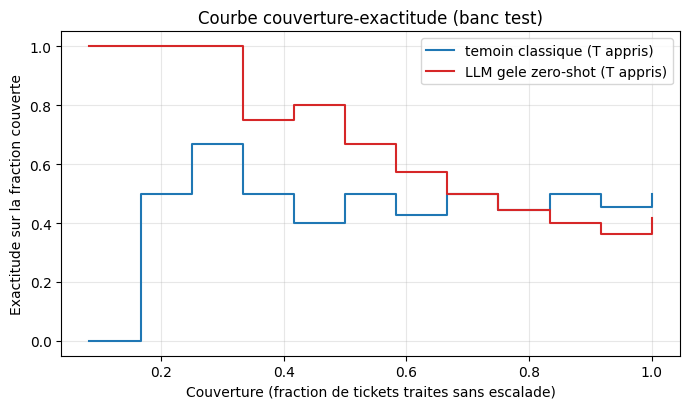

temoin classique   escalade 50 % -> exactitude couverte 0.500
LLM gele           escalade 50 % -> exactitude couverte 0.667


In [9]:
def courbe_couverture_exactitude(P, y):
    """Exactitude sur la fraction la plus confiante des questions, pour chaque couverture."""
    conf = P.max(1)
    ok = (P.argmax(1) == y)
    ordre = np.argsort(-conf)
    couv, acc = [], []
    for k in range(1, len(y) + 1):
        sel = ordre[:k]
        couv.append(k / len(y))
        acc.append(float(ok[sel].mean()))
    return np.array(couv), np.array(acc)


fig, ax = plt.subplots(figsize=(7, 4.2))
for nom, P, coul in [
    ("temoin classique (T appris)", P_clf_test_T, "tab:blue"),
    ("LLM gele zero-shot (T appris)", P_llm_test_T, "tab:red"),
]:
    c, a = courbe_couverture_exactitude(P, y_test_idx)
    ax.step(c, a, where="post", label=nom, color=coul)
ax.set_xlabel("Couverture (fraction de tickets traites sans escalade)")
ax.set_ylabel("Exactitude sur la fraction couverte")
ax.set_title("Courbe couverture-exactitude (banc test)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for nom, P in [("temoin classique", P_clf_test_T), ("LLM gele", P_llm_test_T)]:
    conf = P.max(1)
    seuil = np.quantile(conf, 0.5)  # couverture cible 50 %
    couverts = conf >= seuil
    print(
        f"{nom:18s} escalade 50 % -> exactitude couverte "
        f"{(P.argmax(1)[couverts] == y_test_idx[couverts]).mean():.3f}"
    )

### Lecture du résultat

La courbe répond à la question posée en ouverture : **quand un petit modèle suffit-il ?** —
quand, à la couverture visée, son exactitude couverte est au niveau acceptable, **et** que sa
confiance est calibrée (sinon le seuil ne veut rien dire). Mesuré ici, et contre l'intuition :
à 50 % d'escalade, c'est le LLM gelé qui couvre le mieux (0,667 contre 0,500) — ses erreurs
sont moins concentrées sur ses réponses les plus confiantes. Sur 12 tickets de test, ce constat
est une **observation à répliquer**, pas une conclusion. Le résidu au-delà du seuil n'est pas
un échec du modèle : c'est le flux qu'on **route** délibérément vers l'humain ou le LLM
génératif. Décider, ce n'est pas toujours répondre — c'est aussi savoir quand ne pas répondre.

## 7. Exercices

Trois exercices, du plus mécanique au plus ouvert. Chaque stub s'exécute tel quel
(`return None`), le notebook reste exécutable de bout en bout.

### Exercice 1 — Étendre le contrat au type ordinal `score`

Le type `score` déclare une échelle ordinale (ex. gravité 1-5) au lieu d'options nominales.
Écrire `question_score` qui renvoie la distribution sur l'échelle.

In [10]:
def question_score(state, echelle=("1", "2", "3", "4", "5")):
    """Exercice 1 : distribution typée sur une échelle ordinale de gravité.

    TODO etudiant : soumettre l'état au LLM gelé (fonction option_scores) pour chaque
    niveau de l'échelle et renvoyer la distribution.
    Indice : un `score` se traite comme un `choice` sur N niveaux — mais l'exactitude
    stricte n'est plus la bonne métrique (voir Exercice 2 pour pourquoi).
    """
    print("Exercice a completer")
    return None


# question_score("Le site est totalement inaccessible depuis deux heures")

### Exercice 2 — Une métrique ordinale : la distance absolue moyenne

Sur une échelle 1-5, prédire 4 quand la vérité est 5 est une *meilleure* décision que prédire
1 — l'exactitude stricte compte les deux comme fausses. Écrire `mad_ordinal` qui mesure la
distance absolue moyenne entre niveau prédit et niveau vrai.

In [11]:
def mad_ordinal(predictions_idx, verite_idx):
    """Exercice 2 : distance absolue moyenne entre niveaux prédits et niveaux vrais.

    TODO etudiant : renvoyer la moyenne de |prediction - verite| sur le banc.
    Indice : les distributions de l'Exercice 1 se réduisent à un niveau par argmax.
    """
    print("Exercice a completer")
    return None


# mad_ordinal([4, 2, 5], [5, 2, 3])  # attendu : (1 + 0 + 2) / 3 = 1.0

### Exercice 3 — Politique d'escalade à budget fixé

Le support peut traiter 60 % des tickets sans humain. Écrire `seuil_pour_couverture` qui,
à partir des confiances calibrées, trouve le seuil réalisant exactement cette couverture —
puis mesurer l'exactitude couverte des deux familles à ce budget.

In [12]:
def seuil_pour_couverture(confiances, couverture=0.6):
    """Exercice 3 : seuil de confiance réalisant la couverture visée.

    TODO etudiant : renvoyer le plus petit seuil tel qu'au moins `couverture` des tickets
    aient une confiance >= seuil.
    Indice : np.quantile fait presque tout le travail — attention au sens de l'inégalité.
    """
    print("Exercice a completer")
    return None


# s = seuil_pour_couverture(P_clf_test_T.max(1), 0.6)

## 8. Conclusion — et les familles ouvertes, en tranches suivantes

**Ce que cette tranche a établi.** Un contrat à espace fermé rend les erreurs de type
impossibles par construction, mais reporte toute la difficulté sur la **calibration** — et la
calibration s'acquiert avec un jeu dédié **et dimensionné** : sur 12 tickets, la température
apprise dégrade la confiance au lieu de la réparer. Sur ce banc minuscule, l'écart mesuré
entre les familles (0,500 contre 0,417 en exactitude brute ; 0,500 contre 0,667 en exactitude
couverte à 50 % d'escalade) **n'est pas concluant** — et le fait que le LLM gelé couvre mieux
à budget égal, là où on attendait l'inverse, est exactement le genre de surprise qu'un banc
didactique sert à rencontrer sans conclure. Le LLM gelé achète l'accès immédiat à tout domaine
nouveau sans entraînement ; le témoin classique achète des microsecondes par question, au prix
d'étiquettes à chaque extension du domaine.

**Tranches suivantes de l'issue #17883** (chacune = une PR, déclarées ici pour ne pas les
substituer par un jouet) :

| Famille | Représentant | Ce qu'elle ajoute |
|---|---|---|
| Encodeur + tête de décision | laya, Von (ModernBERT ~400 M) | le fine-tuning bat le zéro-shot… sur le banc d'entraînement |
| Adaptateur LoRA + tête | Kev (Qwen 0.8B/4B/9B) | sert le contrat HTTP tel quel |
| Entraîneur minimal CPU | jevlike | tête d'attention par option, contrôle « contexte mélangé » |
| **Banc externe** | banc indépendant multi-tâches | mesure de l'écart zéro-shot **hors domaine** (~26 points rapportés) |

**Références** : issue #17883 (cadre complet) · #17878 (le volet entraînement, dans
`PostTraining`) · `03_Structured_Outputs` (la voie générative) · `13_Agentic_Orchestration` (où une
décision typée alimente l'agent).